0. Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

1. Loading the dataset

Loading the dataset and presenting information and the first rows of the dataset:

In [ ]:
df = pd.read_csv('../data/raw/Churn_Modelling.csv')
df.info() 
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


2. Data preprocessing

2.1. Checking the amount of missing values (nulls) in the dataframe columns:

In [ ]:
df.isnull().mean() * 100

RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64

There are no null values in any column, so no treatment is required.

2.2. Plotting boxplots for numerical columns where identifying potential outliers is worthwhile (columns with 0 or 1 values were excluded):

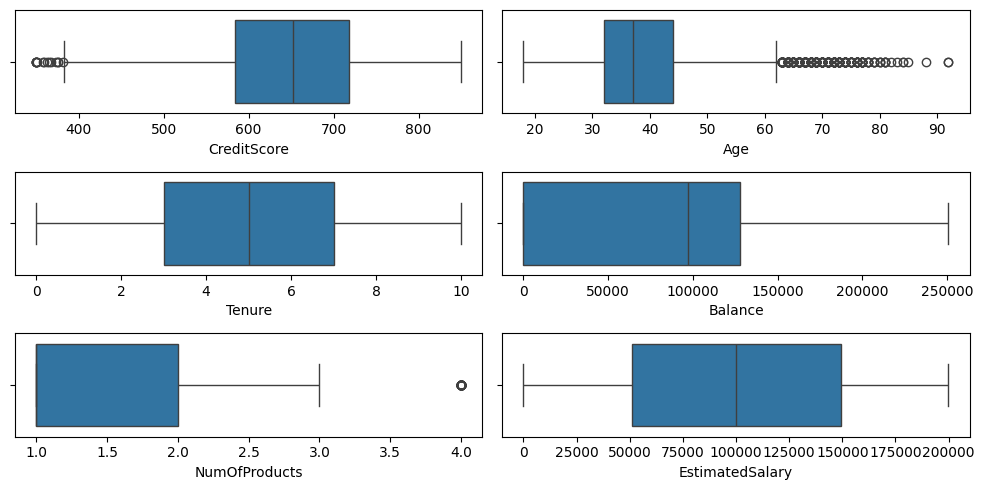

In [ ]:
plt.figure(figsize=(10, 5))

cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
for i in range(6):
    #Criando uma grade de 3 linhas e 2 colunas
    plt.subplot(3, 2, i+1)
    #Criando boxplot
    sns.boxplot(data=df, x=cols[i])

plt.tight_layout()

- **CreditScore:** There are customers with credit scores below what is considered common;
- **Age:** There are many customers with very advanced ages, exceeding what is considered common;
- **Tenure:** Most customers have between 3 to 7 years of membership;
- **Balance:** The vast majority of customers have between 0 and 150 thousand reais;
- **NumOfProducts:** Most customers use between 1 and 2 products, but there are exceptions with a higher number of products;
- **EstimatedSalary:** Most have a salary between 50 and 150 thousand.

2.3. Exploring basic statistics for continuous numerical columns:

In [ ]:
df.iloc[:, 3:14].describe() #Selecionando todas as linhas e obtendo descrição dos dados das colunas

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Credit Score:**
- Average: 650.5288
- Maximum: 850
- 50% of clients have a credit score below 652;

**Age:**
- Average: 38.9218
- Maximum: 92
- 75% of clients are under 44 years old;

**Tenure:**
- Average: 5.0128
- Maximum: 10
- Uniform membership time;

**Balance:**
- Average: 76,485.889288
- Maximum: 250,898.09
- At least 25% of clients have a balance equal to 0, and a dispersion equal to approximately 0.82, indicating very spread-out and heterogeneous values; 

**NumOfProducts:**
- Average: 1,5302
- Maximum: 4
- More than 50% (less than 75%) of customers are below average;

**HasCreditCard:**
- At least 50% of customers have a credit card;

**IsActiveMember:**
- At least 50% of customers are active;

**EstimatedSalary:**
- Average: 100,090.239881
- Maximum: 199,992.480000
- Apparently uniform values, but the lowest estimated salary is 11.58;

**Exited:**
- At least 75% have not left the bank.

3. Data mining

3.1. Plotting histograms and bar charts of the key columns for univariate analysis:

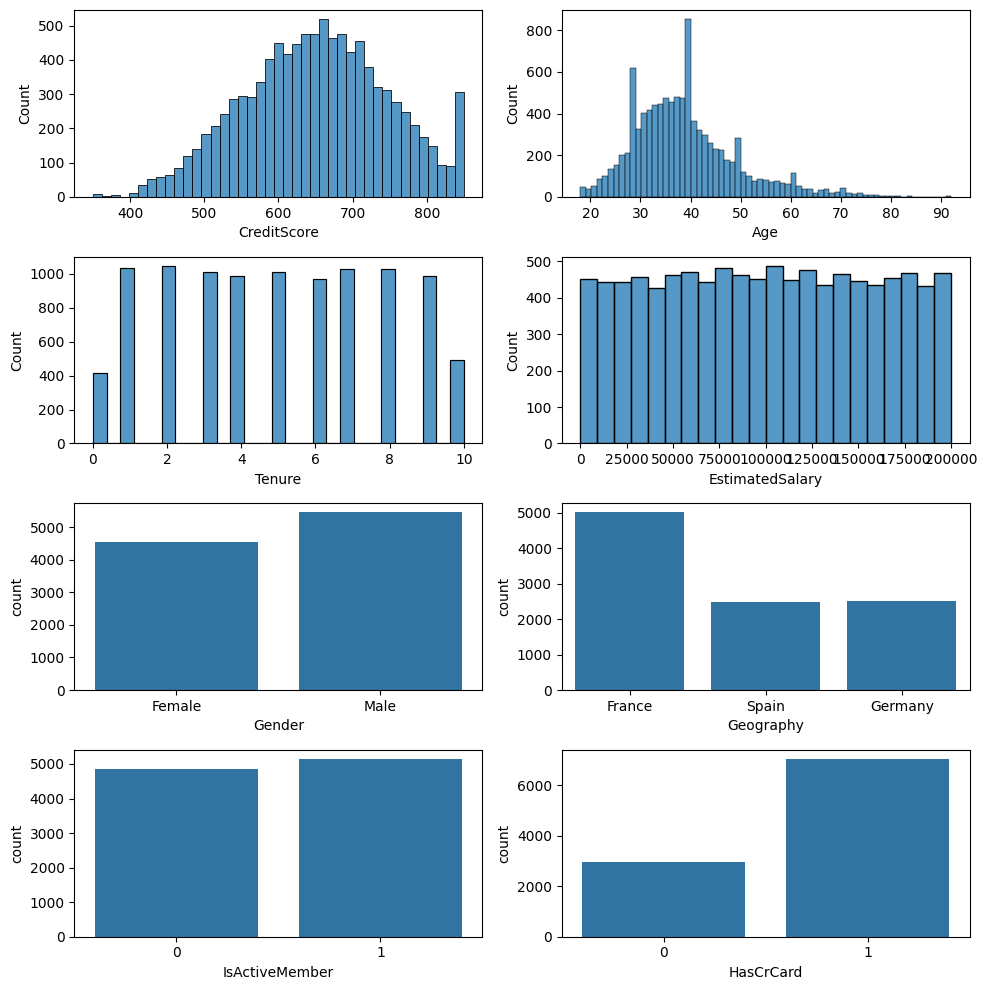

In [ ]:
plt.figure(figsize=(10, 10))

cols = ['CreditScore', 'Age', 'Tenure', 'EstimatedSalary', 'Gender', 'Geography', 'IsActiveMember', 'HasCrCard']
for i, col in enumerate(cols):
    plt.subplot(4, 2, i+1)
    if i<4:
        sns.histplot(data=df, x=col)
    else:
        sns.countplot(data=df, x=col)

plt.tight_layout()

- **CreditScore:** The distribution is symmetrical, with the majority of customer credit scores concentrated between 600 and 700. There are atypical cases with a high number of credit scores;
- **Age:** The distribution is left-skewed, meaning that most customers are younger, concentrated mainly between 30 and 50 years old, with some numbers much higher than others in the same range, and there are also cases of very old people;
- **Tenure:** The distribution of customer membership time in years is approximately uniform. There are atypical cases with customers having very little time (between 0 and 1) and a lot of time (between 9 and 10);
- **EstimatedSalary:** The distribution of estimated customer salary is very uniform;
- **Gender:** The distribution of CreditScore is slightly uniform between genders, with males standing out;
- **Geography:** The distribution concentrates approximately 50% of customers living in France, with the other half being divided evenly among the remainder;
- **IsActiveMember:** The distribution is uniform, with just over 50% of customers being active;
- **HasCard:** The majority of customers have a card, about twice as many as those who do not.

3.2. Explorando as relações, para a análise bivariada, entre:

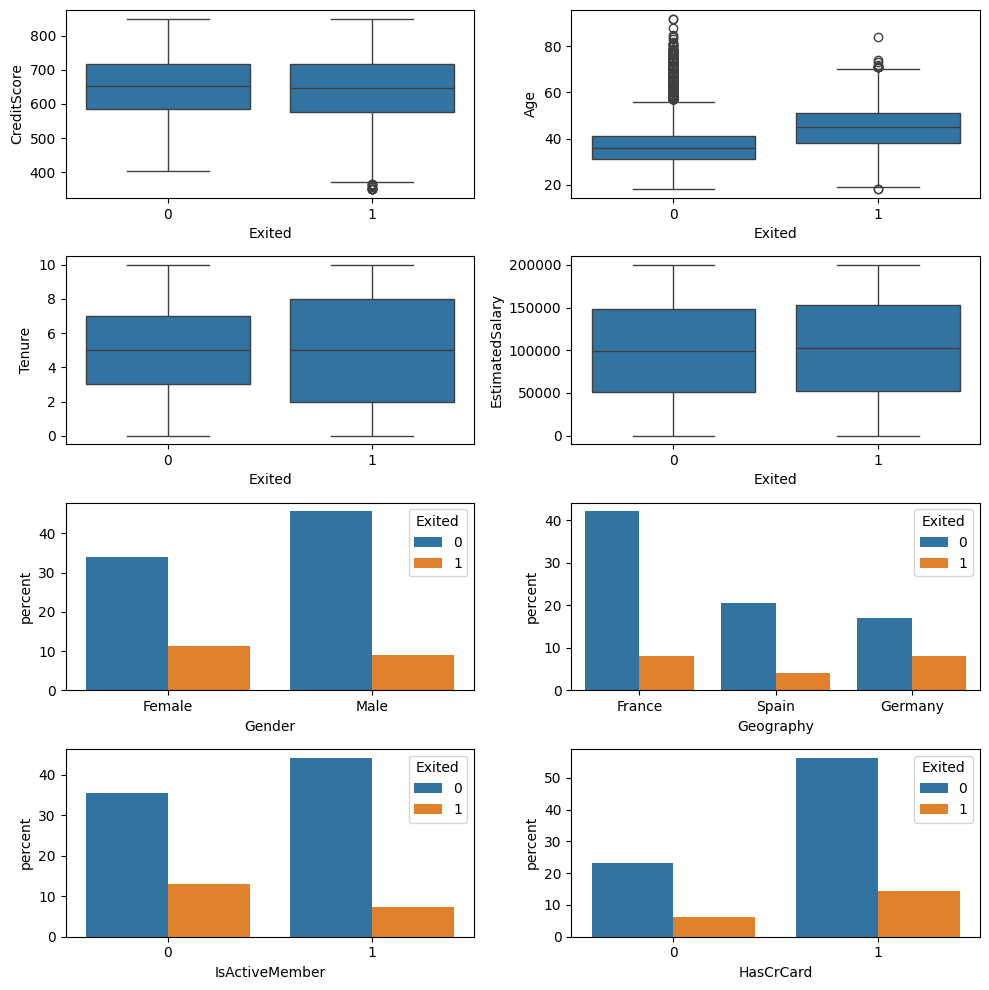

In [ ]:
plt.figure(figsize=(10, 10))

cols = ['CreditScore', 'Age', 'Tenure', 'EstimatedSalary', 'Gender', 'Geography', 'IsActiveMember', 'HasCrCard']
for i in range(8):
    plt.subplot(4, 2, i+1)
    if i<=3:
        sns.boxplot(x='Exited', y=cols[i], data=df)
    else:
        sns.countplot(x=cols[i], hue='Exited', data=df, stat='percent')

plt.tight_layout()

- **Exited x Credit Score:** Exit or retention is uniform in relation to credit score, that is, there is no clear difference between those who left or stayed. There are some atypical cases regarding those who left, indicating clients with values ​​that deviate from the general trend;
- **Exited x Age:** The median rating of clients who did not leave ranges between 30 and 40 years, with half of those who continued being between around 30 and just over 40 years old, with some advanced ages (50+) among those who stayed. The median rating of clients who left ranges between 40 and 50 years, with half of those who left ranging between just under 40 and 50 years old, with a few advanced ages (70+) among those who left;
- **Exited x Tenure:** The median rating of clients who did not leave is around 5 years of membership, with half of those who continued ranging between 3 and 7 years of membership. The median classification of departing customers is around 5 years of membership, with half of those who remained fluctuating between just over 2 and just under 7 years of membership;
- **Exited x Estimated Salary:** Departure or retention is uniform in relation to estimated salary, therefore, salary does not seem to influence the decision to leave.
- **Exited x Gender:** Around 10-15% of female customers left the bank, while around 10% of male customers left the bank;
- **Exited x Geography:** Around 5-10% of French and German customers left the bank, while Spanish customers account for around 5%;
- **Exited x Is Active Member:** Among inactive customers, around 10-15% left, while among active customers, around 5-10% left. Inactive customers have a churn rate approximately 2x higher than active customers;
- **Exited vs. HasCreditCard:** Among customers without a credit card, around 5% churned, while among those with a card, around 15% churned. Those without a card have a churn rate approximately 3 times higher than those with one.

4. Pattern evaluation

- Age, Tenure, Gender, Geography, IsActiveMember, and HasCrCard provide interesting data regarding output;
- Various factors influence output, with no pattern regarding categorical or numerical factors;
- CreditScore, Age, and NumOfProducts present outliers, with all representing genuine outliers.